In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ClassicalCode import ClassicalCode
from LogicalChannel import LogicalChannel
from measures import stochastic_distance, l1_stochastic_distance, is_stochastic
from error_models import (perfect_physical_error, iid_syndrome,
                          sticky_syndrome, exp_syndrome_1)
from random_codes import sample_H_brute
from nonmarkov_plots import A_heatmaps

# Non-Markovian Error Models

Temporally correlated syndrome noise (`sticky_syndrome`, `exp_syndrome_1`) and (t, q) heatmaps of the logical stochastic matrix. The generalized `A_heatmaps` driver lives in `nonmarkov_plots.py`.

In [2]:
n = 5
k = 1
Tmax = 2000
q = 0.1

code = ClassicalCode(sample_H_brute(n,k))
channel = LogicalChannel(code, Tmax, q)
divisible = channel.is_divisible()



121
122
124
125
127
128
130
132
133
136
137
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
155
157
158
160


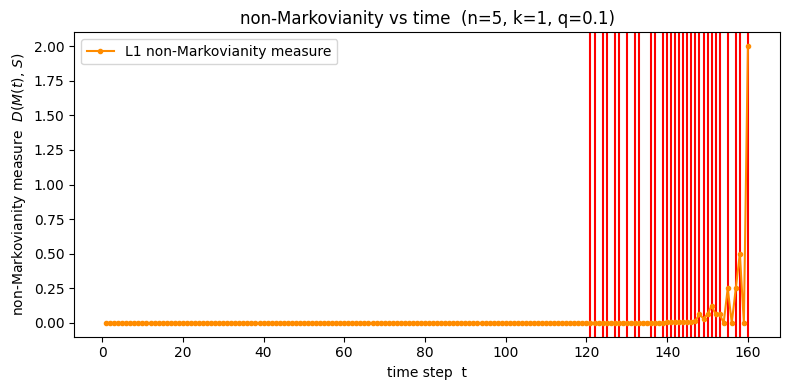

In [3]:
A  = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts = list(range(1, Tmax + 1))

measure_l1 = []
measure_frob = []

plt.figure(figsize=(8, 4))

for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_l1.append(np.nan)  # singular step: propagator undefined
        #measure_frob.append(np.nan)
    else:
        if not divisible[1][t]:
            plt.axvline(t, color='r')
            print(t)
        measure_l1.append(l1_stochastic_distance(M))
        #measure_frob.append(stochastic_distance(M))


plt.plot(ts, measure_l1, marker='o', ms=3, color='darkorange', label='L1 non-Markovianity measure')
#plt.plot(ts, measure_frob, marker='o', ms=3, color='blue', label = r'Frobenious measure')
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'non-Markovianity vs time  (n={code.n}, k={code.k}, q={q})')

plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# ---- Inspect a non-divisible (singular) step of the channel built above ----
# The one-step propagator M = A_t @ inv(A_{t-1}) is undefined when A_{t-1} is
# singular; those are exactly the steps is_divisible flags as False.  We pick the
# first such step automatically (the old hard-coded a=1319 was specific to one
# random draw of `code`, so it crashed on a fresh sample).
nondiv = [t for t in range(1, Tmax + 1) if not divisible[1][t]]
a = nondiv[0] if nondiv else Tmax          # first non-divisible step, else last step
print('non-divisible steps (first 10):', nondiv[:10], '...' if len(nondiv) > 10 else '')
print(f'inspecting step a = {a}   divisible[{a}] = {divisible[1][a]}')

A = channel.stochastic_matrix(a)
B = channel.stochastic_matrix(a - 1)
print('A =\n', A)
print('B =\n', B)
print('det(B) =', np.linalg.det(B))

if abs(np.linalg.det(B)) < 1e-12:
    print('B is singular -> one-step propagator A @ inv(B) is undefined at this step')
else:
    M = A @ np.linalg.inv(B)
    print('inv(B) =\n', np.linalg.inv(B))
    print('A @ inv(B) =\n', M)
    print('is_stochastic(A @ inv(B)):', is_stochastic(M))

print('row-0 sum of B:', B[0][0] + B[0][1])


non-divisible steps (first 10): [121, 122, 124, 125, 127, 128, 130, 132, 133, 136] ...
inspecting step a = 121   divisible[121] = False
A =
 [[0.5 0.5]
 [0.5 0.5]]
B =
 [[0.5 0.5]
 [0.5 0.5]]
det(B) = 2.3490098755074663e-12
inv(B) =
 [[ 2.1285564e+11 -2.1285564e+11]
 [-2.1285564e+11  2.1285564e+11]]
A @ inv(B) =
 [[0.89996338 0.10003662]
 [0.1000061  0.8999939 ]]
is_stochastic(A @ inv(B)): False
row-0 sum of B: 1.000000000000017


## Non-Markovian syndrome-error model (no physical errors)

Syndrome error `e_t` repeats the previous one `e_{t-1}` with probability `q`, otherwise it is freshly drawn from an i.i.d. bit-flip(`p`) distribution — a sticky (memory-1) process on the syndrome-error sequence (`sticky_syndrome`). The data qubits are noiseless (`perfect_physical_error`), so the only dynamics come from the temporally correlated measurement noise. Set `q` (memory) and `p` (fresh bit-flip rate) below.

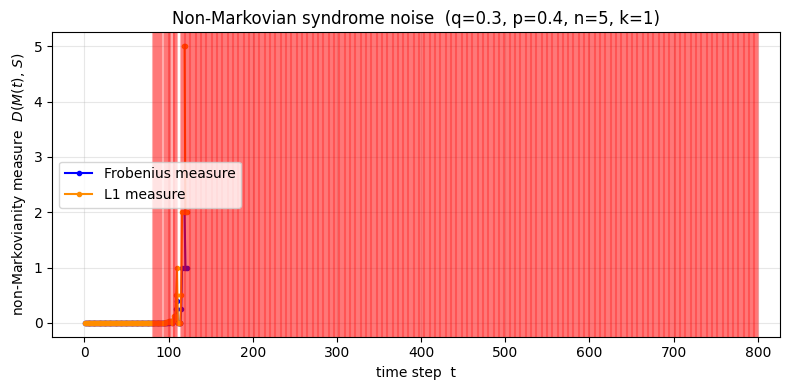

divisible (Markovian) over all steps: False


In [5]:
# ---- Non-Markovian (temporally correlated) syndrome errors, no physical errors ----
# Syndrome-error model:  e_t = e_{t-1}  with probability q,
#                        else freshly drawn from an i.i.d. bit-flip(p) distribution.
# The physical channel is PERFECT (no data errors), so every bit of logical
# dynamics comes from the temporally correlated syndrome-measurement noise.
from error_models import perfect_physical_error, sticky_syndrome
from measures import stochastic_distance, l1_stochastic_distance

q    = 0.3      # probability the syndrome error repeats the previous step (memory)
p    = 0.4      # bit-flip parameter of the fresh-draw distribution
Tmax = 800

#code_nm = ClassicalCode(np.array([[1, 1, 0], [0, 1, 1]]))         # swap in any code here

n = 5
k = 1

code_nm = ClassicalCode(sample_H_brute(n,k))

channel = LogicalChannel(code_nm, Tmax, q,
                         p_error=perfect_physical_error,           # no physical errors
                         syndrome=sticky_syndrome(code_nm, q, p))  # correlated syndrome noise

A         = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts        = list(range(1, Tmax + 1))
divisible = channel.is_divisible()

measure_frob, measure_l1 = [], []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_frob.append(np.nan)
        measure_l1.append(np.nan)
    else:
        measure_frob.append(stochastic_distance(M))
        measure_l1.append(l1_stochastic_distance(M))

plt.figure(figsize=(8, 4))
plt.plot(ts, measure_frob, marker='o', ms=3, color='blue',       label='Frobenius measure')
plt.plot(ts, measure_l1,   marker='o', ms=3, color='darkorange', label='L1 measure')
for t in ts:
    if not divisible[1][t]:
        plt.axvline(t, color='r', alpha=0.3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'Non-Markovian syndrome noise  '
          f'(q={q}, p={p}, n={code_nm.n}, k={code_nm.k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('divisible (Markovian) over all steps:', divisible[0])

## Experimental two-step-history model (`exp_syndrome_1`)

An arbitrary, explicitly history-dependent syndrome process (memory 2) for probing non-Markovianity. For `t ≥ 2`: if `(e_{t-1} XOR e_{t-2})` is the all-ones string, the next syndrome error is forced to all-ones with probability `q` (else i.i.d. bit-flip(`p`)); otherwise it is i.i.d. bit-flip(`p`). The data qubits are noiseless (`perfect_physical_error`). With `q = 1` the all-ones history deterministically pins `e_t`. Red lines mark steps where the one-step propagator fails to be stochastic (non-divisible ⇒ non-Markovian).

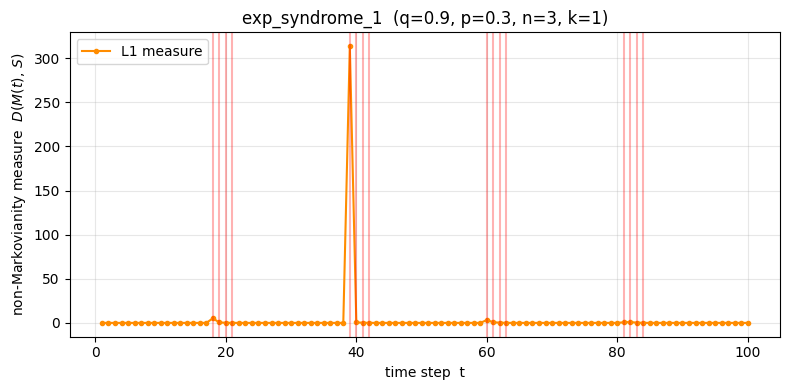

divisible (Markovian) over all steps: False
non-divisible steps: [18, 19, 20, 21, 39, 40, 41, 42, 60, 61, 62, 63, 81, 82, 83, 84]


In [6]:
# ---- Experimental two-step-history syndrome model (exp_syndrome_1) ----
# For t >= 2, if  (e_{t-1} XOR e_{t-2}) == 11...1  (all-ones), then e_t is forced
# to all-ones with probability q, else i.i.d. bit-flip(p).  Otherwise e_t is just
# i.i.d. bit-flip(p).  Physical channel is perfect (no data errors).
# Both q (forcing prob) and p (i.i.d. fallback rate) are baked into exp_syndrome_1.
from error_models import perfect_physical_error, exp_syndrome_1
from measures import stochastic_distance, l1_stochastic_distance

q    = 0.9      # forcing probability when the all-ones history condition fires
p    = 0.3      # i.i.d. bit-flip fallback rate
Tmax = 100

code_exp = ClassicalCode(np.array([[1, 1, 0],
                                    [0, 1, 1]]))        # swap in any code here
channel  = LogicalChannel(code_exp, Tmax, q,
                          p_error=perfect_physical_error,           # no physical errors
                          syndrome=exp_syndrome_1(code_exp, q, p))  # 2-step history process

A         = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
ts        = list(range(1, Tmax + 1))
divisible = channel.is_divisible()

measure_frob, measure_l1 = [], []
for t in ts:
    try:
        M = A[t] @ np.linalg.inv(A[t - 1])
    except np.linalg.LinAlgError:
        measure_frob.append(np.nan)
        measure_l1.append(np.nan)
    else:
        measure_frob.append(stochastic_distance(M))
        measure_l1.append(l1_stochastic_distance(M))

plt.figure(figsize=(8, 4))
#plt.plot(ts, measure_frob, marker='o', ms=3, color='blue',       label='Frobenius measure')
plt.plot(ts, measure_l1,   marker='o', ms=3, color='darkorange', label='L1 measure')
for t in ts:
    if not divisible[1][t]:
        plt.axvline(t, color='r', alpha=0.3)
plt.xlabel('time step  t')
plt.ylabel(r'non-Markovianity measure  $D(M(t),\,S)$')
plt.title(f'exp_syndrome_1  (q={q}, p={p}, n={code_exp.n}, k={code_exp.k})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/exp_syndrome_1')
plt.show()

print('divisible (Markovian) over all steps:', divisible[0])
print('non-divisible steps:', [t for t in ts if not divisible[1][t]])

saved: plots/exp_syndrome_1 mean non-Markovianity vs q (p=0.3, n=3, k=1, Tmax=40).png


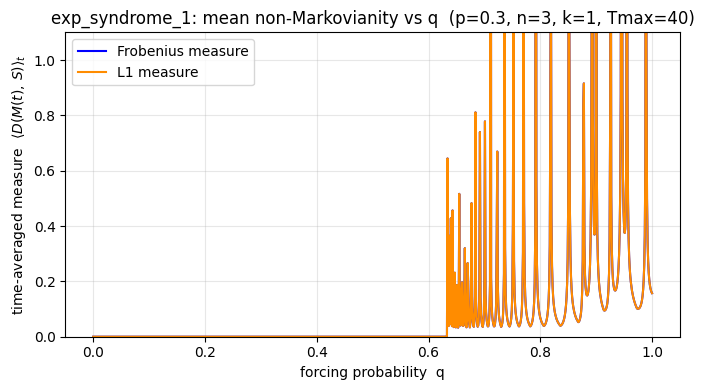

In [7]:
# ---- exp_syndrome_1: time-averaged non-Markovianity measure vs q ----
# Coarse 0.1 grid on [0.0, 0.5], then a fine 0.001 grid on [0.6, 1.0] so the
# behaviour near q -> 1 is resolved.  (Do NOT np.round(qs, 1): that collapses the
# fine grid back onto the 0.1 grid and was the bug in the previous version.)
import os, re
from error_models import perfect_physical_error, exp_syndrome_1
from measures import stochastic_distance, l1_stochastic_distance

p    = 0.3      # i.i.d. bit-flip fallback rate
Tmax = 40
qs   = np.concatenate([np.arange(0.0, 0.6, 0.1),            # coarse 0.0 .. 0.5
                       np.arange(0.6, 1.0 + 1e-9, 0.001)])  # fine   0.6 .. 1.0

code_exp = ClassicalCode(np.array([[1, 1, 0],
                                    [0, 1, 1]]))        # swap in any code here

mean_frob, mean_l1 = [], []
for q in qs:
    channel = LogicalChannel(code_exp, Tmax, q,
                             p_error=perfect_physical_error,
                             syndrome=exp_syndrome_1(code_exp, q, p))
    A = [channel.stochastic_matrix(t) for t in range(Tmax + 1)]
    vf, vl = [], []
    for t in range(1, Tmax + 1):
        try:
            M = A[t] @ np.linalg.inv(A[t - 1])
        except np.linalg.LinAlgError:
            vf.append(np.nan); vl.append(np.nan)        # singular step
        else:
            vf.append(stochastic_distance(M))
            vl.append(l1_stochastic_distance(M))
    mean_frob.append(np.nansum(vf) / Tmax)              # sum of measures / total steps
    mean_l1.append(np.nansum(vl) / Tmax)

title = (f'exp_syndrome_1: mean non-Markovianity vs q  '
         f'(p={p}, n={code_exp.n}, k={code_exp.k}, Tmax={Tmax})')

plt.figure(figsize=(7, 4))
plt.plot(qs, mean_frob, color='blue',       label='Frobenius measure')
plt.plot(qs, mean_l1,   color='darkorange', label='L1 measure')
plt.xlabel('forcing probability  q')
plt.ylabel(r'time-averaged measure  $\langle D(M(t),\,S)\rangle_t$')
plt.title(title)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# save to plots/ with a filename derived from the title (strip Windows-illegal chars)
os.makedirs('plots', exist_ok=True)
fname = re.sub(r'[<>:"/\|?*]', '', title).strip()
fname = re.sub(r'\s+', ' ', fname) + '.png'
plt.savefig(os.path.join('plots', fname), dpi=150, bbox_inches='tight')
print('saved:', os.path.join('plots', fname))

plt.show()

#print('Frobenius:', dict(zip(np.round(qs, 3), np.round(mean_frob, 6))))
#print('L1       :', dict(zip(np.round(qs, 3), np.round(mean_l1, 6))))


## Stochastic matrix $A_t$ over $(t, q)$ — invertibility & monotonicity

Two heatmaps of the logical stochastic matrix $A_t$ with **x = time step**, **y = error rate**.

- **Left — $\det(A_t)$:** whether $A_t$ is invertible. $\det=0$ means **singular** (non-invertible). For a $k=1$ code $A_t=\begin{psmallmatrix}1-p_L & p_L\\ p_L & 1-p_L\end{psmallmatrix}$, so $\det(A_t)=1-2p_L(t)$, and it is singular exactly when the logical flip probability hits $\tfrac12$ (maximally mixed logical bit). This is the same singularity that `is_divisible` reports as *not divisible*.
- **Right — $A_{00}(t)$:** the logical survival probability. **Monotone decrease is consistent with a Markovian (P-divisible) channel; a revival (increase) is information backflow ⇒ non-Markovian.** Revival cells are marked in red.

The cell below runs the **both-noisy iid** channel (memory 0 ⇒ Markovian control); the generalized function further down sweeps *any* `LogicalChannel` builder (sticky, exp_syndrome_1, …).

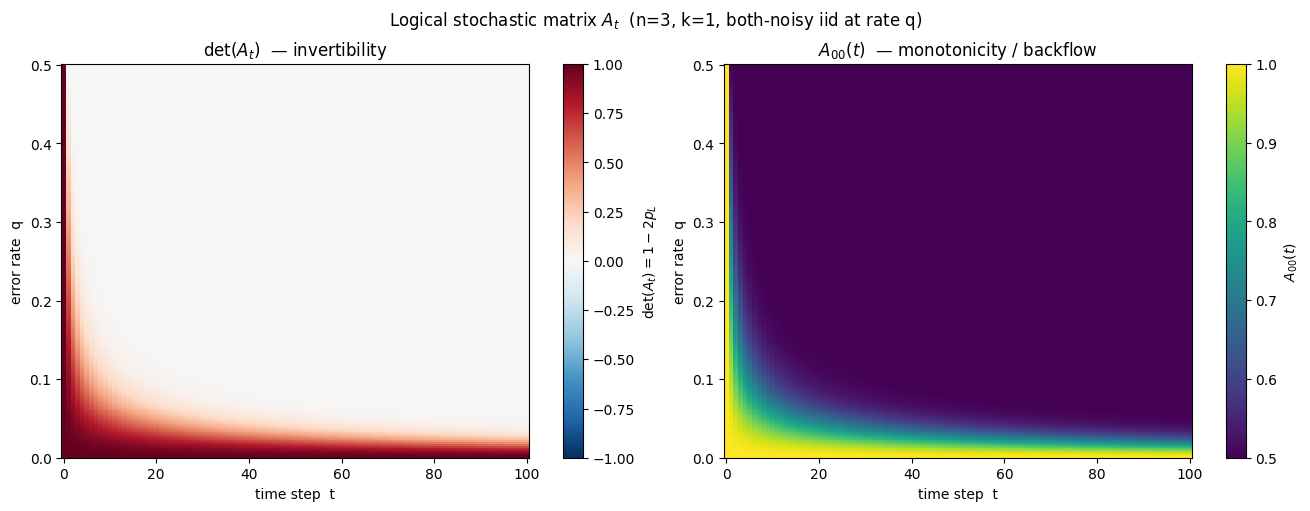

det(A_t) range: 0.0 .. 1.0  (>=0 => invertible everywhere at finite t)
A00 revivals (non-Markovian cells): 0


In [8]:
# ---- (t, q) heatmaps of the logical stochastic matrix A_t ----
# Left : det(A_t)          -> invertibility.  For k=1, det(A_t) = A00 - A01 = 1 - 2 p_L(t),
#                             so det = 0  <=>  singular  <=>  p_L = 1/2 (max-mixed logical).
# Right: A00(t) = survival -> monotonicity.  A monotone-decreasing A00 is consistent with a
#                             Markovian (P-divisible) channel; an *increase* (revival) is
#                             information backflow => NON-Markovian.  Revivals are marked in red.
import os
from matplotlib.colors import TwoSlopeNorm

code_A = ClassicalCode(np.array([[1, 1, 0], [0, 1, 1]]))   # 3-bit repetition code (k=1)
Tmax   = 100
qs     = np.linspace(1e-3, 0.5, 200)                        # error rate (both physical & syndrome, iid)
ts     = np.arange(Tmax + 1)

det = np.empty((len(qs), Tmax + 1))
A00 = np.empty_like(det)
for i, q in enumerate(qs):
    channel = LogicalChannel(code_A, Tmax, q)               # both noisy, iid, at rate q
    for t in ts:
        A = channel.stochastic_matrix(t)
        det[i, t] = np.linalg.det(A)
        A00[i, t] = A[0, 0]
det = np.where(np.abs(det) < 1e-12, 0.0, det)               # squash float noise around 0

# pixel edges so integer t and each q row are centred
tedge = np.arange(-0.5, Tmax + 1.5, 1.0)
dq    = (qs[1] - qs[0]) / 2
qedge = np.concatenate(([qs[0] - dq], (qs[:-1] + qs[1:]) / 2, [qs[-1] + dq]))
Tg, Qg = np.meshgrid(tedge, qedge)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# --- determinant / invertibility ---
pm1 = ax1.pcolormesh(Tg, Qg, det, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), shading='flat')
#cs = ax1.contour(ts, qs, det, levels=[0.05, 0.2, 0.5, 0.9], colors='k', linewidths=0.9, alpha=0.6)
#ax1.clabel(cs, fmt='%.2f', fontsize=7)
ax1.set(xlabel='time step  t', ylabel='error rate  q', title=r'$\det(A_t)$  — invertibility')
#ax1.text(0.5, 0.04, r'$\det>0$ at all finite $t$  $\Rightarrow$  $A_t$ invertible',transform=ax1.transAxes, ha='center', fontsize=8)
fig.colorbar(pm1, ax=ax1, label=r'$\det(A_t) = 1 - 2p_L$')

# --- A00 / monotonicity & backflow ---
pm2 = ax2.pcolormesh(Tg, Qg, A00, cmap='viridis', vmin=0.5, vmax=1.0, shading='flat')
revival = np.diff(A00, axis=1) > 1e-12                      # A00 went back up => non-Markovian
ri, rt = np.where(revival)
if revival.sum():
    ax2.scatter(ts[rt + 1], qs[ri], s=6, c='red', label=f'revival (A00 up): {int(revival.sum())} cells')
    ax2.legend(loc='upper right', fontsize=8)
#else:
    #ax2.text(0.5, 0.05, 'no revivals: monotone decay (Markovian)', transform=ax2.transAxes, ha='center', fontsize=9, color='white')
ax2.set(xlabel='time step  t', ylabel='error rate  q', title=r'$A_{00}(t)$  — monotonicity / backflow')
fig.colorbar(pm2, ax=ax2, label=r'$A_{00}(t)$')

fig.suptitle(f'Logical stochastic matrix $A_t$  (n={code_A.n}, k={code_A.k}, both-noisy iid at rate q)', fontsize=12)
os.makedirs('plots', exist_ok=True)
fig.savefig('plots/A_det_A00_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

print('det(A_t) range:', det.min(), '..', det.max(), ' (>=0 => invertible everywhere at finite t)')
print('A00 revivals (non-Markovian cells):', int(revival.sum()))


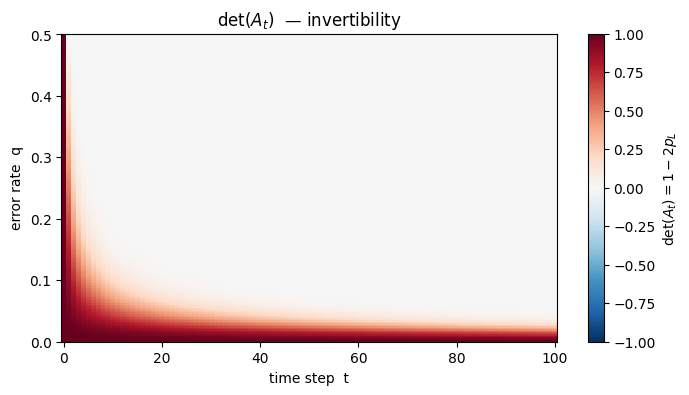

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

# --- determinant / invertibility ---
pm1 = ax.pcolormesh(Tg, Qg, det, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), shading='flat')
#cs = ax1.contour(ts, qs, det, levels=[0.05, 0.2, 0.5, 0.9], colors='k', linewidths=0.9, alpha=0.6)
#ax1.clabel(cs, fmt='%.2f', fontsize=7)
ax.set(xlabel='time step  t', ylabel='error rate  q', title=r'$\det(A_t)$  — invertibility')
#ax1.text(0.5, 0.04, r'$\det>0$ at all finite $t$  $\Rightarrow$  $A_t$ invertible',transform=ax1.transAxes, ha='center', fontsize=8)
fig.colorbar(pm1, label=r'$\det(A_t) = 1 - 2p_L$')


plt.savefig('plots/A_det_A00_heatmaps_single.png', dpi=150, bbox_inches='tight')

plt.show()

### Generalized version — same heatmaps for any error model

`A_heatmaps(make_channel, param_values, Tmax, ...)` takes a **builder** `make_channel(param, Tmax) -> LogicalChannel`, so the identical $\det(A_t)$ / $A_{00}(t)$ pair works for **any** model — just change how the channel is built and what the y-axis sweeps. Demos below run **iid** (Markovian control), **`sticky_syndrome`** (memory-1), and **`exp_syndrome_1`** (memory-2). For this code the iid and sticky sweeps stay monotone, while `exp_syndrome_1` develops $A_{00}$ **revivals** (red) and drives $\det$ negative (a genuine singular crossing) at high forcing probability — the non-Markovian regime. *(Note: `is_divisible` tests P-divisibility of the one-step propagator, a stronger condition than $A_{00}$ monotonicity — a model can be non-divisible yet still have monotone $A_{00}$, e.g. sticky here.)*

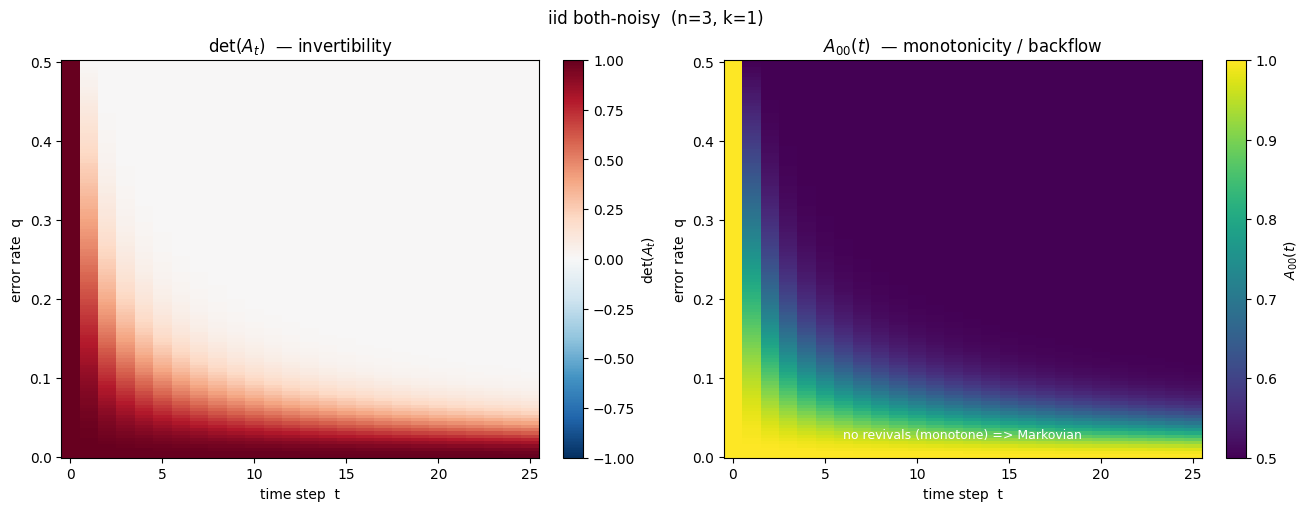

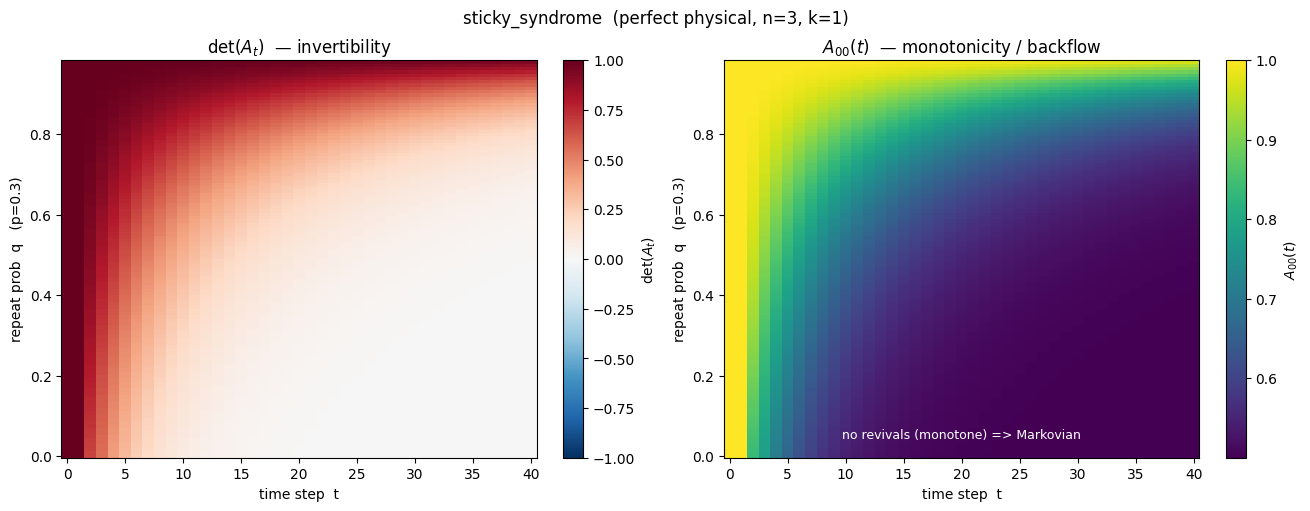

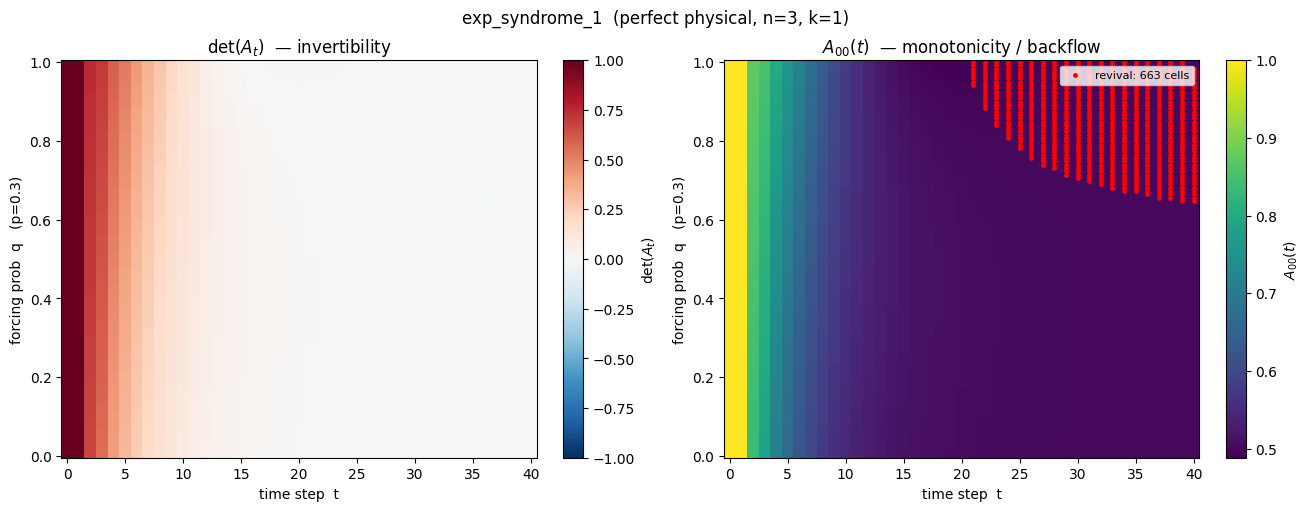

In [10]:
# ---- demos: same two plots across the notebook's error models ----
code_A = ClassicalCode(np.array([[1, 1, 0], [0, 1, 1]]))
p = 0.3     # fresh/fallback bit-flip rate for the correlated models

# 1) iid both-noisy (memory 0 -> Markovian control)
A_heatmaps(lambda q, T: LogicalChannel(code_A, T, q),
           np.linspace(1e-3, 0.5, 120), 25,
           param_label='error rate  q',
           title=f'iid both-noisy  (n={code_A.n}, k={code_A.k})',
           save='plots/A_heatmaps_iid.png')

# 2) sticky_syndrome (perfect physical) -- sweep the memory/repeat probability q
A_heatmaps(lambda q, T: LogicalChannel(code_A, T, q, p_error=perfect_physical_error,
                                       syndrome=sticky_syndrome(code_A, q, p)),
           np.linspace(0.0, 0.98, 120), 40,
           param_label=f'repeat prob  q   (p={p})',
           title=f'sticky_syndrome  (perfect physical, n={code_A.n}, k={code_A.k})',
           save='plots/A_heatmaps_sticky.png')

# 3) exp_syndrome_1 (perfect physical) -- sweep the forcing probability q
A_heatmaps(lambda q, T: LogicalChannel(code_A, T, q, p_error=perfect_physical_error,
                                       syndrome=exp_syndrome_1(code_A, q, p)),
           np.linspace(0.0, 1.0, 120), 40,
           param_label=f'forcing prob  q   (p={p})',
           title=f'exp_syndrome_1  (perfect physical, n={code_A.n}, k={code_A.k})',
           save='plots/A_heatmaps_exp.png')

plt.show()

# Non Markovian Behaviour explore

## Independent Random Noise on Physical Bits

We want to make sure this non markovianity is not model based. First, keep the physical errors independent. Sample (2n-k)*T numbers of random numbers between 0 and 1 and then use them as probability for errors of each bit. Go through around 1000 instances and see if any non markovian behaviour arises.

### Random Independent Errors for only Physical bits

In [2]:
# 3 bit Repetition Code
from error_models import perfect_syndrome, iid_bitflip_error
from time_dependent_channel import (physical_only, syndrome_only, combined,
                                     ScheduleChannel)

code = ClassicalCode(np.array([[1, 1, 0,0, 0], [0, 1, 1,0,0], [0,0,1,1,0],[0,0,0,1,1]]))   # n=3, m=2, k=1
Tmax = 50
n_instances = 5000
rng = np.random.default_rng(0)

In [3]:
# ---- sanity check: a CONSTANT, equal-across-bits rate must reproduce
#      LogicalChannel exactly (physical only -> perfect syndrome) ----
q = 0.17
A_td = physical_only(code, Tmax, np.full((code.n, Tmax), q))   # every bit, every step = q
lc   = LogicalChannel(code, Tmax, q, p_error=iid_bitflip_error,
                      syndrome=perfect_syndrome(code))
maxdiff = max(np.max(np.abs(A_td[t] - lc.stochastic_matrix(t))) for t in range(Tmax + 1))
print(f'constant-rate q={q}: max |A_time_dependent - A_LogicalChannel| = {maxdiff:.2e}')
assert maxdiff < 1e-12, 'time-dependent builder disagrees with LogicalChannel!'
print('OK -- builder reproduces LogicalChannel exactly at a constant rate.')


constant-rate q=0.17: max |A_time_dependent - A_LogicalChannel| = 0.00e+00
OK -- builder reproduces LogicalChannel exactly at a constant rate.


#### Single random instance ($T_{max}=3$)

Sample $n \times T_{max} = 3 \times 3 = 9$ independent flip probabilities (one per data bit per step) and read off the logical snapshots $A_t$ and divisibility. The `ScheduleChannel` adapter exposes the same `stochastic_matrix` / `is_divisible` API as `LogicalChannel`, so all the earlier analysis reuses unchanged.

In [4]:
# ---- one random instance: n x Tmax independent per-bit, per-step flip probabilities ----

p_phys = rng.random((code.n, Tmax))        # p_phys[bit, step] in [0, 1]; here 3 x 3 = 9 numbers
print('per-bit, per-step physical flip probabilities  p_phys[bit, step]:')
print(np.round(p_phys, 3))

ch = ScheduleChannel(code, physical_only(code, Tmax, p_phys))   # LogicalChannel-like read API
#for t in range(Tmax + 1):
#    print(f'\nA_{t} =\n{np.round(ch.stochastic_matrix(t), 4)}')

divisible, per_step = ch.is_divisible()
print('\ndivisible (Markovian) over all steps:', divisible)
print('per-step stochastic(M(t)):', per_step)


per-bit, per-step physical flip probabilities  p_phys[bit, step]:
[[0.637 0.27  0.041 0.017 0.813 0.913 0.607 0.729 0.544 0.935 0.816 0.003
  0.857 0.034 0.73  0.176 0.863 0.541 0.3   0.423 0.028 0.124 0.671 0.647
  0.615 0.384 0.997 0.981 0.686 0.65  0.688 0.389 0.135 0.721 0.525 0.31
  0.486 0.889 0.934 0.358 0.572 0.322 0.594 0.338 0.392 0.89  0.227 0.623
  0.084 0.833]
 [0.787 0.239 0.876 0.059 0.336 0.15  0.45  0.796 0.231 0.052 0.405 0.199
  0.091 0.58  0.299 0.672 0.2   0.942 0.365 0.105 0.629 0.927 0.44  0.955
  0.5   0.425 0.62  0.995 0.949 0.46  0.758 0.497 0.529 0.786 0.415 0.734
  0.711 0.932 0.115 0.729 0.927 0.968 0.015 0.864 0.981 0.957 0.149 0.973
  0.89  0.822]
 [0.48  0.232 0.802 0.924 0.266 0.539 0.443 0.931 0.041 0.732 0.614 0.028
  0.719 0.016 0.758 0.513 0.929 0.066 0.841 0.067 0.344 0.43  0.966 0.562
  0.259 0.242 0.888 0.226 0.125 0.288 0.586 0.554 0.81  0.56  0.288 0.413
  0.818 0.627 0.959 0.369 0.553 0.594 0.848 0.145 0.407 0.91  0.043 0.823
  0.415 0.83 ]
 [

#### Monte Carlo over ~1000 random schedules

Repeatedly sample independent per-bit, per-step physical error probabilities and count how many give a non-divisible (non-Markovian) logical channel.

In [11]:
# ---- Fast Monte Carlo (precomputed-context engine): are independent per-bit,
#      per-step PHYSICAL errors ever GENUINELY non-Markovian? ----
from time_dependent_channel import monte_carlo_first_steps

phys_steps = monte_carlo_first_steps(code, Tmax, n_instances, 'phys', rng=rng)
print(f'{len(phys_steps)} / {n_instances} independent-physical schedules are GENUINELY '
      f'NON-Markovian   (n={code.n}, k={code.k}, Tmax={Tmax})')
if len(phys_steps) == 0:
    print('=> independent physical noise (corrected each step) stays Markovian; the '
          'non-Markovianity elsewhere comes from correlated / syndrome structure.')
else:
    print('first genuine non-Markovian steps (first 10):', phys_steps[:10].tolist())


0 / 5000 independent-physical schedules are GENUINELY NON-Markovian   (n=5, k=1, Tmax=50)
=> independent physical noise (corrected each step) stays Markovian; the non-Markovianity elsewhere comes from correlated / syndrome structure.


### Random Independent Error For Only Syndrome Bits

In [12]:
# ---- fast genuine non-Markov count for independent SYNDROME errors ----
syn_steps = monte_carlo_first_steps(code, Tmax, n_instances, 'syn', rng=rng)
print(f'{len(syn_steps)} / {n_instances} independent-syndrome schedules are GENUINELY '
      f'NON-Markovian   (n={code.n}, k={code.k}, Tmax={Tmax})')
if len(syn_steps):
    print('first genuine non-Markovian steps (first 10):', syn_steps[:10].tolist())


4468 / 5000 independent-syndrome schedules are GENUINELY NON-Markovian   (n=5, k=1, Tmax=50)
first genuine non-Markovian steps (first 10): [6, 12, 9, 8, 7, 6, 7, 4, 3, 4]


### Random Independent Error for Both Physcal and Syndrome Error

In [ ]:
# ---- fast genuine non-Markov count for independent BOTH (physical + syndrome) ----
comb_steps = monte_carlo_first_steps(code, Tmax, n_instances, 'comb', rng=rng)
print(f'{len(comb_steps)} / {n_instances} independent (both) schedules are GENUINELY '
      f'NON-Markovian   (n={code.n}, k={code.k}, Tmax={Tmax})')
if len(comb_steps):
    print('first genuine non-Markovian steps (first 10):', comb_steps[:10].tolist())


Result: for long enough time, all channels aside from physical noise become eventually non-markovian. It seems it takes time for non-markovianity to emerge.

In [ ]:
# PLOT — ratio of non-Markovian instances over the number of Monte-Carlo samples.
# 2D heatmaps (x = number of samples, y = Tmax), one per case: physical / syndrome
# / combined.  Colourbar fixed to [0, 1].
#
# "Non-Markovian" here = GENUINE non-divisibility.  The maximally mixed logical
# state [[.5,.5],[.5,.5]] (det = 0) is the channel's absorbing fixed point, and
# |det(A_t)| shrinks monotonically to 0; near-singular A_{t-1} makes the propagator
# M(t) = A_t inv(A_{t-1}) a 0/0 artifact.  So the counting (see monte_carlo_nonmarkov):
#   * once |det(A_t)| and the next `absorb_window` are all < det_thresh -> the fixed
#     point is reached; stop tracking.
#   * skip any step whose predecessor A_{t-1} is below det_thresh (undefined inverse).
# An instance counts as non-Markovian only if some well-conditioned step is genuinely
# non-stochastic before absorption.
import os
from time_dependent_channel import monte_carlo_nonmarkov

sample_counts = [10, 100, 500, 1000, 5000]      # x-axis (cumulative: column n uses the first n samples)
Tmaxs         = [10, 30, 50, 100, 150]          # y-axis
cases = [('phys', 'physical only'), ('syn', 'syndrome only'), ('comb', 'combined')]
det_thresh, absorb_window = 1e-6, 3
cache = 'plots/nonmarkov_ratio_grid.npz'

if os.path.exists(cache):                        # reuse the precomputed grid if present
    d = np.load(cache)
    ratios = {c: d[c] for c, _ in cases}
    sample_counts, Tmaxs = list(d['sample_counts']), list(d['Tmaxs'])
    print('loaded cached grid from', cache)
else:                                            # ~7 min: 3 cases x 5 Tmax x 5000 samples
    n_max = max(sample_counts)
    ratios = {}
    for case, _ in cases:
        R = np.zeros((len(Tmaxs), len(sample_counts)))
        for i, T in enumerate(Tmaxs):
            res = monte_carlo_nonmarkov(code, T, n_max, case,
                                        rng=np.random.default_rng(1000 + i),
                                        det_thresh=det_thresh, absorb_window=absorb_window,
                                        checkpoints=sample_counts)
            R[i, :] = [res[c] for c in sample_counts]
        ratios[case] = R
        print(case, 'done')
    os.makedirs('plots', exist_ok=True)
    np.savez(cache, sample_counts=sample_counts, Tmaxs=Tmaxs, **ratios)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
im = None
for ax, (case, title) in zip(axes, cases):
    R = ratios[case]
    im = ax.imshow(R, origin='lower', aspect='auto', vmin=0, vmax=1, cmap='viridis')
    ax.set_xticks(range(len(sample_counts))); ax.set_xticklabels(sample_counts)
    ax.set_yticks(range(len(Tmaxs)));         ax.set_yticklabels(Tmaxs)
    ax.set_xlabel('number of samples'); ax.set_ylabel('Tmax'); ax.set_title(title)
    for i in range(len(Tmaxs)):
        for j in range(len(sample_counts)):
            v = R[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v < 0.55 else 'black', fontsize=8)
fig.colorbar(im, ax=axes, label='non-Markovian ratio', shrink=0.9)
fig.suptitle(f'Genuine non-Markovian ratio  (n={code.n}, k={code.k})', fontsize=12)
os.makedirs('plots', exist_ok=True)
fig.savefig('plots/nonmarkov_ratio_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


### First step where genuine non-Markovianity appears

For every random schedule that is *genuinely* non-Markovian, record the earliest step at which the one-step propagator $M(t) = A_t A_{t-1}^{-1}$ fails to be stochastic (using the same absorption-aware rule), and histogram it over the samples — one panel per case. Physical-only is always Markovian, so its panel is empty.

In [ ]:
# PLOT 2 — histogram of the step at which GENUINE non-Markovianity first appears,
# aggregated over many random schedules (one panel per case).  Uses the same
# absorption-aware rule (first_nonmarkov_step): Markovian samples contribute nothing.
import os
from time_dependent_channel import monte_carlo_first_steps

Tmax_hist = 150
n_hist    = 5000
cases = [('phys', 'physical only'), ('syn', 'syndrome only'), ('comb', 'combined')]
cache_h = 'plots/first_step_hist.npz'

steps_by = None
if os.path.exists(cache_h):
    d = np.load(cache_h)
    if int(d['Tmax']) == Tmax_hist and int(d['n']) == n_hist:
        steps_by = {c: d[c] for c, _ in cases}
        print('loaded cached first-steps from', cache_h)
if steps_by is None:                             # ~3 min otherwise
    steps_by = {c: monte_carlo_first_steps(code, Tmax_hist, n_hist, c,
                                            rng=np.random.default_rng(7))
                for c, _ in cases}
    os.makedirs('plots', exist_ok=True)
    np.savez(cache_h, Tmax=Tmax_hist, n=n_hist, **steps_by)

nonempty = [s for s in steps_by.values() if len(s)]
hi = int(np.concatenate(nonempty).max()) if nonempty else 1
bins = np.arange(0.5, hi + 1.5, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
for ax, (case, title) in zip(axes, cases):
    s = steps_by[case]
    if len(s):
        ax.hist(s, bins=bins, color='darkorange', edgecolor='white', linewidth=0.3)
        ax.set_title(f'{title}\n{len(s)}/{n_hist} non-Markovian (median step {int(np.median(s))})')
    else:
        ax.set_title(f'{title}\n0/{n_hist} non-Markovian')
        ax.text(0.5, 0.5, 'always Markovian', transform=ax.transAxes,
                ha='center', va='center', color='gray')
    ax.set_xlabel('first genuine non-Markovian step  t'); ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('number of samples')
fig.suptitle(f'First genuine non-Markovian step  (n={code.n}, k={code.k}, '
             f'Tmax={Tmax_hist}, {n_hist} samples)')
fig.tight_layout()
fig.savefig('plots/first_nonmarkov_step_hist.png', dpi=150, bbox_inches='tight')
plt.show()


## Deciding if Non Markovianity Depend on Syndrome of Code

In this case, we would be using the same code, but just switch through the syndromes by multiplying full rank matrices to the parity check matrix. This way we would be using the same code but with different syndromes.

In [9]:
# ---- Syndrome dependence with a FIXED error set: same code, same syndrome-error
#      schedule, only the syndrome RELABELING H' = P H changes (P in GL(m, F_2)). ----
# Left-multiplying the parity-check matrix by an invertible m x m P (m = n - k) keeps
# the SAME code (codewords / distance) but relabels the syndromes and the decoder.
# We first find ONE syndrome-error schedule that is genuinely non-Markovian for the
# base code, then hold it FIXED and vary only the relabeling -- isolating the effect
# of the syndrome labeling.  (|GL(m, F_2)| distinct relabelings: 20160 for m = 4.)
from time_dependent_channel import sample_genuine_schedule, monte_carlo_relabel

n_instances = 1000
Tmax = 100

# fixed syndrome-error schedule, genuinely non-Markovian for the base code
p_syn_fixed = sample_genuine_schedule(code, Tmax, 'syn', rng=np.random.default_rng(5))['p_syn']

tavg_relabel, relabel_steps = monte_carlo_relabel(code, Tmax, p_syn_fixed, n_instances,
                                                  rng=np.random.default_rng(11))
print(f'{len(relabel_steps)} / {n_instances} syndrome-relabelings (SAME error set) are '
      f'GENUINELY NON-Markovian   (n={code.n}, k={code.k}, m={code.m}, Tmax={Tmax})')
if len(relabel_steps):
    print(f'first genuine non-Markovian step:  median={int(np.median(relabel_steps))}, '
          f'min={relabel_steps.min()}, max={relabel_steps.max()}')
print(f'time-averaged L1 measure across relabelings:  mean={tavg_relabel.mean():.3f}, '
      f'std={tavg_relabel.std():.3f}  (std > 0 => relabeling changes non-Markovianity)')


961 / 1000 syndrome-relabelings (SAME error set) are GENUINELY NON-Markovian   (n=5, k=1, m=4, Tmax=100)
first genuine non-Markovian step:  median=11, min=3, max=13
time-averaged L1 measure across relabelings:  mean=0.049, std=0.064  (std > 0 => relabeling changes non-Markovianity)


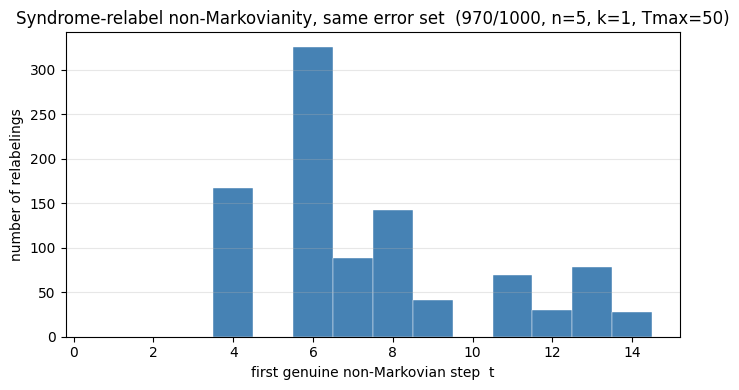

In [6]:
# ---- Histogram: first genuine non-Markovian step across syndrome relabelings (fixed error set) ----
import os
if len(relabel_steps):
    hi = int(relabel_steps.max())
    plt.figure(figsize=(7, 4))
    plt.hist(relabel_steps, bins=np.arange(0.5, hi + 1.5, 1.0),
             color='steelblue', edgecolor='white', linewidth=0.3)
    plt.xlabel('first genuine non-Markovian step  t')
    plt.ylabel('number of relabelings')
    plt.title(f'Syndrome-relabel non-Markovianity, same error set  '
              f'({len(relabel_steps)}/{n_instances}, n={code.n}, k={code.k}, Tmax={Tmax})')
    plt.grid(alpha=0.3, axis='y'); plt.tight_layout()
    os.makedirs('plots', exist_ok=True)
    plt.savefig('plots/syndrome_relabel_first_step_hist.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('all relabelings Markovian -- nothing to histogram')


## L1 measure vs time (one genuine non-Markovian instance)

Take one recorded schedule flagged as *genuinely* non-Markovian — independent **syndrome-only** and **combined** — and plot its L1 measure $D(M(t)) = $ `l1_stochastic_distance`$(A_t A_{t-1}^{-1})$ vs time. Spikes are the non-Markovian (non-divisible) steps; singular / absorbed steps are left blank.

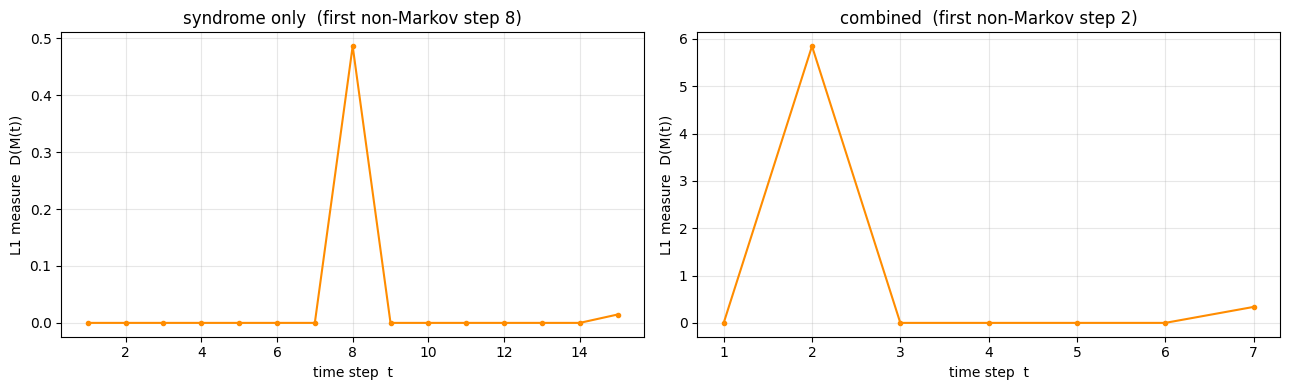

In [7]:
# ---- L1 measure vs time for ONE flagged (genuine non-Markovian) instance, per case ----
from time_dependent_channel import sample_genuine_schedule, l1_measure_vs_time

Tmax_rev = 80
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (case, title) in zip(axes, [('syn', 'syndrome only'), ('comb', 'combined')]):
    rec = sample_genuine_schedule(code, Tmax_rev, case, rng=np.random.default_rng(0))
    ts, measure, _, _ = l1_measure_vs_time(rec['A'])   # D(M(t)); NaN at singular/absorbed steps
    ax.plot(ts, measure, marker='o', ms=3, color='darkorange')
    ax.set_xlabel('time step  t'); ax.set_ylabel('L1 measure  D(M(t))')
    ax.set_title(f'{title}  (first non-Markov step {rec["first_step"]})')
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.savefig('plots/l1_measure_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()


## Does syndrome relabeling change the time-averaged non-Markovianity?

Fix the n=5 repetition code and one syndrome-error schedule (`p_syn_fixed`, found above) that is genuinely non-Markovian. Vary **only** the syndrome relabeling $H' = P H$ ($P \in GL(m,\mathbb{F}_2)$). For each relabeling compute the time-averaged L1 measure $\langle D(M(t))\rangle_t = \tfrac{1}{T_{max}}\sum_t D(M(t))$, and plot its **running mean vs number of samples** together with the **variance** of the collected values. A nonzero variance means the syndrome labeling *does* change the non-Markovianity.

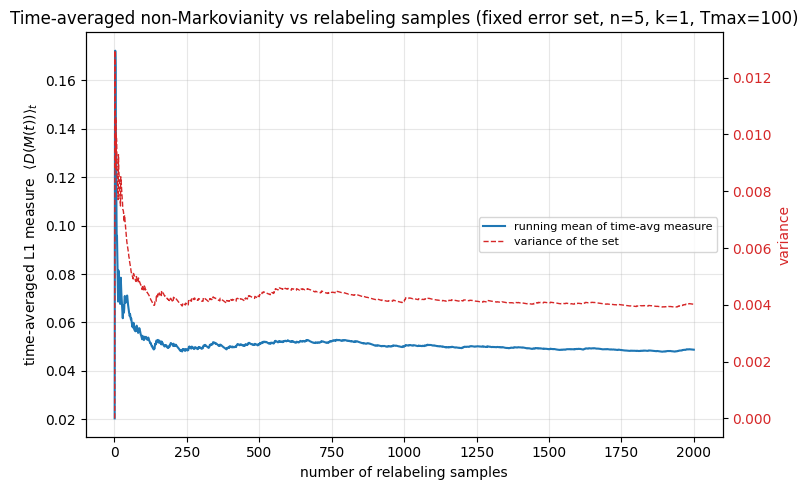

final over 2000 relabelings:  mean=0.0488, variance=0.0040, std=0.0634


In [10]:
# ---- Does syndrome relabeling change the TIME-AVERAGED non-Markovianity? ----
# Fixed error set (p_syn_fixed, from the cell above); vary only the relabeling.
# Plot running MEAN of the time-averaged L1 measure vs number of relabeling samples,
# plus the VARIANCE of the collected measures.  ~2 min at N_max=2000 (~60 ms/sample;
# |GL(4,F2)| = 20160 distinct relabelings, so mean/variance converge well before).
import os
from time_dependent_channel import monte_carlo_relabel

N_max = 2000
tavg, _ = monte_carlo_relabel(code, Tmax, p_syn_fixed, N_max, rng=np.random.default_rng(21))

ns = np.arange(1, N_max + 1)
run_mean = np.cumsum(tavg) / ns
run_var  = np.maximum(np.cumsum(tavg**2) / ns - run_mean**2, 0.0)   # variance of the set of measures
run_std  = np.sqrt(run_var)



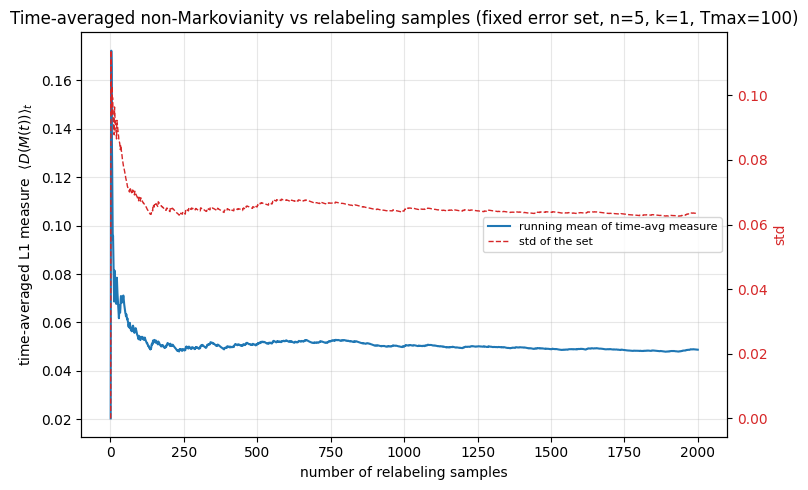

final over 2000 relabelings:  mean=0.0488, variance=0.0040, std=0.0634


In [11]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, run_mean, color='C0', label='running mean of time-avg measure')
#ax.fill_between(ns, run_mean - run_std, run_mean + run_std, color='C0', alpha=0.2, label=r'$\pm1$ std (spread across relabelings)')
ax.set_xlabel('number of relabeling samples')
ax.set_ylabel(r'time-averaged L1 measure  $\langle D(M(t))\rangle_t$')
ax.set_title(f'Time-averaged non-Markovianity vs relabeling samples '
             f'(fixed error set, n={code.n}, k={code.k}, Tmax={Tmax})')
ax.grid(alpha=0.3)

ax2 = ax.twinx()
ax2.plot(ns, run_std, color='C3', lw=1, ls='--', label='std of the set')
ax2.set_ylabel('std', color='C3'); ax2.tick_params(axis='y', labelcolor='C3')

h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='center right', fontsize=8)
fig.tight_layout()
os.makedirs('plots', exist_ok=True)
fig.savefig('plots/relabel_time_avg_measure.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'final over {N_max} relabelings:  mean={run_mean[-1]:.4f}, '
      f'variance={run_var[-1]:.4f}, std={run_std[-1]:.4f}')